In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from scipy.stats import sem
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.contrast import Contrast

In [2]:
def parse_completed_tasks(row):
    try:
        task_data = json.loads(row["completedTasks"].replace("'", '"'))
        return len(task_data), len(task_data.keys())
    except:
        return 0, 0

def infer_condition(group):
    if "role" not in group.columns:
        return "pooled"
    has_roles = group["role"].notna().any()
    return "reciprocal" if has_roles else "pooled"

role_to_stage = {
    "AVERAGE PEOPLE": 1,
    "MAXIMUM INCOME": 2,
    "CHILDREN'S COMMUTE DISTANCE": 3,
}

correct_answers = {
    "neighborhood_1": {
        1: 2,
        2: 60000,
        3: 10
    },
    "neighborhood_2": {
        1: 3,
        2: 54000,
        3: 29
    },
    "neighborhood_3": {
        1: 3,
        2: 83000,
        3: 26
    },
    "neighborhood_4": {
        1: 2,
        2: 75000,
        3: 18
    },
    "neighborhood_5": {
        1: 2,
        2: 54000,
        3: 16
    },
    "neighborhood_6": {
        1: 3,
        2: 66500,
        3: 30
    },
    "neighborhood_7": {
        1: 2,
        2: 139046,
        3: 28
    },
    "neighborhood_8": {
        1: 2,
        2: 115000,
        3: 28
    },
    "neighborhood_9": {
        1: 3,
        2: 187700,
        3: 36
    },
    "neighborhood_10": {
        1: 3,
        2: 125800,
        3: 31
    },
    "neighborhood_11": {
        1: 2,
        2: 108000,
        3: 17
    },
    "neighborhood_12": {
        1: 2,
        2: 90000,
        3: 15
    },
    "neighborhood_13": {
        1: 2,
        2: 120000,
        3: 2
    },
    "neighborhood_14": {
        1: 2,
        2: 200000,
        3: 32
    },
}

In [3]:
def preprocess(filepath):
    import pandas as pd
    import ast
    import hashlib

    def stable_team_id(playerset):
        players_sorted = sorted(playerset)
        joined = ",".join(players_sorted)
        return "team_" + hashlib.md5(joined.encode()).hexdigest()[:8]

    df = pd.read_csv(filepath)

    # ---- STEP 1: Parse all responses ----
    parsed_responses = []
    for _, row in df.iterrows():
        if pd.notna(row.get("responses")):
            try:
                parsed_responses.extend(ast.literal_eval(row["responses"]))
            except:
                continue
    
    responses_df = pd.DataFrame(parsed_responses)

    if "stage" not in responses_df.columns and "column" in responses_df.columns:
        responses_df["stage"] = responses_df["column"]

    # Remove duplicate (playerId, taskId, stage) responses -- happens sometimes when saving to database
    responses_df = responses_df.drop_duplicates(subset=["playerId", "taskId", "stage"])

    # ---- STEP 2: Assign team_id and team_size from ButtonCheck ----
    button_df = df[df["name"] == "ButtonCheck"].copy()
    button_df["activePlayersList"] = button_df["activePlayers"].apply(
        lambda s: set(ast.literal_eval(s)) if pd.notna(s) else set()
    )
    button_df["team_id"] = button_df["activePlayersList"].apply(stable_team_id)
    button_df["team_size"] = button_df["activePlayersList"].apply(len)

    player_to_team = {}
    for _, row in button_df.iterrows():
        for pid in row["activePlayersList"]:
            player_to_team[pid] = (row["team_id"], row["team_size"])

    # ---- STEP 3: Backfill missing team info ----
    player_groups = responses_df.groupby("taskId")["playerId"].apply(set)
    inferred_team_ids = {}
    for players in player_groups:
        known = [player_to_team[pid][0] for pid in players if pid in player_to_team]
        if known:
            canonical_team_id = max(set(known), key=known.count)
            for pid in players:
                if pid not in player_to_team:
                    inferred_team_ids[pid] = canonical_team_id

    def get_team_id(pid):
        if pid in player_to_team:
            return player_to_team[pid][0]
        elif pid in inferred_team_ids:
            return inferred_team_ids[pid]
        return "unknown_team"

    def get_team_size(pid):
        if pid in player_to_team:
            return player_to_team[pid][1]
        elif pid in inferred_team_ids:
            return button_df[button_df["team_id"] == inferred_team_ids[pid]]["team_size"].iloc[0]
        return None

    responses_df["team_id"] = responses_df["playerId"].apply(get_team_id)
    responses_df["team_size"] = responses_df["playerId"].apply(get_team_size)
    responses_df["stage"] = pd.to_numeric(responses_df["stage"], errors="coerce")

    # ---- STEP 4: Stage-based task completion ----
    stages_per_task = (
        responses_df.groupby(["team_id", "taskId"])["stage"]
        .apply(lambda s: set([1, 2, 3]).issubset(set(s)))
        .reset_index(name="completed")
    )
    tasks_completed_per_team = (
        stages_per_task.groupby("team_id")["completed"]
        .sum()
        .reset_index(name="num_tasks_completed")
    )

    # ---- STEP 5: Override using completedTasks ----
    override_entries = []
    for _, row in df.iterrows():
        if pd.notna(row.get("completedTasks")) and pd.notna(row.get("responses")):
            try:
                tasks_dict = ast.literal_eval(row["completedTasks"])
                resp_list = ast.literal_eval(row["responses"])
                if not resp_list:
                    continue
                example_pid = resp_list[0]["playerId"]
                team_id = get_team_id(example_pid)

                def is_completed(task_data):
                    if not isinstance(task_data, dict):
                        return False
                    if set(task_data.keys()) <= {"totalCount"}:
                        return True
                    return task_data.get("totalCount", 0) >= 3

                num_completed = sum(1 for task in tasks_dict.values() if is_completed(task))
                override_entries.append((team_id, num_completed))
            except:
                continue

    override_df = pd.DataFrame(override_entries, columns=["team_id", "num_completed_override"])
    override_df = override_df.groupby("team_id")["num_completed_override"].max().reset_index()

    tasks_completed_per_team = tasks_completed_per_team.merge(
        override_df, on="team_id", how="left"
    )
    tasks_completed_per_team["num_tasks_completed"] = tasks_completed_per_team[
        "num_completed_override"
    ].fillna(tasks_completed_per_team["num_tasks_completed"])
    tasks_completed_per_team.drop(columns=["num_completed_override"], inplace=True)

    # ---- STEP 6: Final merge ----
    team_size_map = responses_df[["team_id", "team_size"]].drop_duplicates()

    if "infer_condition" in globals():
        team_conditions = (
            responses_df.groupby("team_id")
            .apply(infer_condition)
            .reset_index(name="condition")
        )
    else:
        team_conditions = pd.DataFrame(columns=["team_id", "condition"])

    stages_per_team = (
        responses_df.groupby("team_id")["stage"]
        .count()
        .reset_index(name="num_stages_completed")
    )

    full_team_summary = (
        tasks_completed_per_team
        .merge(team_size_map, on="team_id")
        .merge(team_conditions, on="team_id", how="left")
        .merge(stages_per_team, on="team_id")
    )

    full_team_summary = full_team_summary.query("team_size > 2")
    valid_teams = set(full_team_summary["team_id"])
    responses_df = responses_df[responses_df["team_id"].isin(valid_teams)]

    return full_team_summary, responses_df


In [4]:
def plot_team_size_by_tasks_completed(full_team_summary, title):
    agg = (
        full_team_summary
        .groupby(["fault", "condition", "team_size"])["num_tasks_completed"]
        .agg(["mean", sem])
        .reset_index()
        .rename(columns={"mean": "avg_completed", "sem": "sem_completed"})
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    fig.suptitle(title, fontsize=14, weight="bold", y=1.02)
    
    palette = {"pooled": "#1f77b4", "reciprocal": "#ff7f0e"}
    
    for ax, fault_state in zip(axes, [0, 1]):
        sub_fault = agg[agg["fault"] == fault_state]
        for network, color in palette.items():
            sub = sub_fault[sub_fault["condition"] == network].sort_values("team_size")
            x = sub["team_size"].values
            y = sub["avg_completed"].values
            e = sub["sem_completed"].values
            
            ax.plot(x, y,
                    marker="o",
                    markersize=6,
                    linewidth=2,
                    label=network.capitalize(),
                    color=color)
            # shaded CI
            ax.fill_between(x, y - e, y + e,
                            alpha=0.2,
                            color=color,
                            linewidth=0)
        
        ax.set_title("Faults" if fault_state == 1 else "No Faults",
                     fontsize=12, weight="semibold")
        ax.set_xlabel("Team size (members)")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    axes[0].set_ylabel("Tasks completed")
    axes[0].set_ylim(0, full_team_summary["num_tasks_completed"].max() * 1.1)
    
    axes[1].legend_.remove() if axes[1].legend_ else None

    handles, labels = axes[0].get_legend_handles_labels()

    # create a single legend for the whole figure
    fig.legend(
        handles=handles,
        labels=labels,
        title="Network",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=2,
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()
    
    plt.tight_layout()
    # fig.savefig("Experiment1_allconditions.pdf", format="pdf", bbox_inches="tight")
    plt.show()

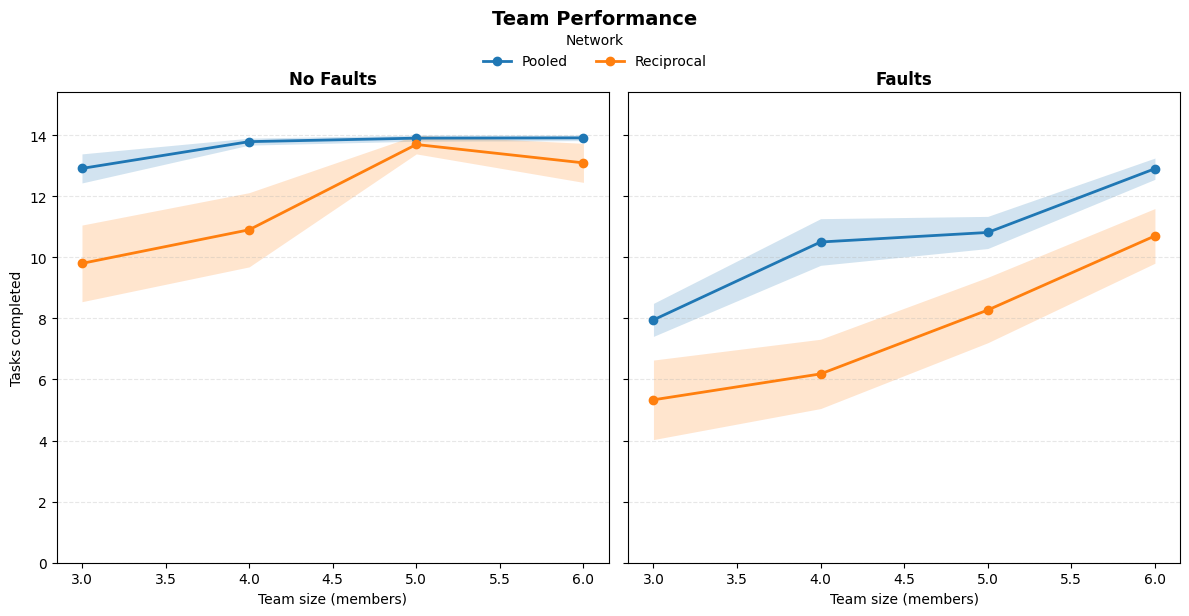

<Figure size 640x480 with 0 Axes>

In [5]:
summary1, responses1 = preprocess("../data/Faults_1/stage.csv")
summary2, responses2 = preprocess("../data/Faults_2/stage.csv")
summary3, responses3 = preprocess("../data/Faults_3/stage.csv")
summary4, responses4 = preprocess("../data/Faults_4/stage.csv")

full_team_summary_1 = pd.concat([summary1, summary2], ignore_index=True)
full_team_summary_2 = pd.concat([full_team_summary_1, summary3], ignore_index=True)
full_team_summary = pd.concat([full_team_summary_2, summary4], ignore_index=True)

responses_df_1 = pd.concat([responses1, responses2], ignore_index=True)
responses_df_2 = pd.concat([responses_df_1, responses3], ignore_index=True)
responses_df = pd.concat([responses_df_2, responses4], ignore_index=True)

# Remove teams with a Prolific server error (couldn't complete any tasks)
rows_to_remove = ["team_51029216", "team_ef47d7ae", "team_0fc5fe76"]
full_team_summary = full_team_summary[~full_team_summary["team_id"].isin(rows_to_remove)]
responses_df = responses_df[~responses_df["team_id"].isin(rows_to_remove)]

fault_summaries = []
for i in [1, 2, 3, 4]:
    summary, _ = preprocess(f"../data/Faults_{i}/stage.csv")
    summary["fault"] = 1           
    fault_summaries.append(summary)

nofault_summaries = []
for i in [1, 2]:
    summary, _ = preprocess(f"../data/NoFaults_{i}/stage.csv")
    summary["fault"] = 0           
    nofault_summaries.append(summary)

full_team_summary_all = pd.concat(
    fault_summaries + nofault_summaries,
    ignore_index=True
)

full_team_summary_all = full_team_summary_all[~full_team_summary_all["team_id"].isin(rows_to_remove)]

plot_team_size_by_tasks_completed(full_team_summary_all, "Team Performance")

In [6]:
# For comparing to Expt 2
full_team_summary_all.to_csv("../data/exp1_team_summary.csv", index=False)
responses_df.to_csv("../data/exp1_responses_long.csv", index=False)

In [7]:
summary1, responses1 = preprocess("../data/NoFaults_1/stage.csv")
summary2, responses2 = preprocess("../data/NoFaults_2/stage.csv")

full_team_summary_nofaults = pd.concat([summary1, summary2], ignore_index=True)
responses_df_nofaults = pd.concat([responses1, responses2], ignore_index=True)

/var/folders/rp/drddpy_10vd_hlk0_w76l5_w0000gn/T/ipykernel_66797/2906755836.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=melted_df, x="team_id", y="count", hue="response_type", palette="Set1", ci=None)


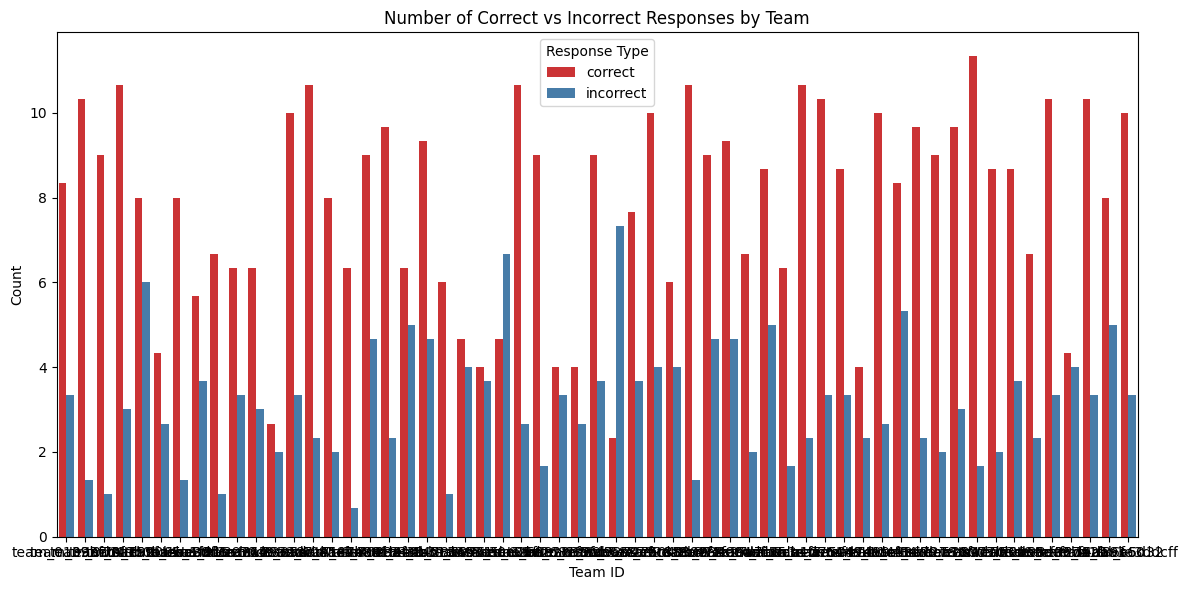

In [8]:
def is_correct(row):
    task  = row["taskId"]
    try:
        stage = int(row["stage"])
    except:
        role = str(row["role"])
        if role == "AVERAGE PEOPLE":
            stage = 1
        elif role == "MAXIMUM INCOME":
            stage = 2
        elif role == "CHILDREN'S COMMUTE DISTANCE":
            stage = 3
        else:
            print(role)
            
    resp  = row["response"]

    correct = correct_answers[task][stage]
    return int(resp) == correct

responses_df["is_correct"] = responses_df.apply(is_correct, axis=1)
responses_df_nofaults["is_correct"] = responses_df_nofaults.apply(is_correct, axis=1)

total_counts = (
    responses_df.dropna(subset=["is_correct"])
    .groupby(["team_id", "stage"])["is_correct"]
    .count()
    .reset_index(name="total")
)

correct_counts = (
    responses_df.dropna(subset=["is_correct"])
    .groupby(["team_id", "stage"])["is_correct"]
    .sum()
    .reset_index(name="correct")
)

plot_df = pd.merge(total_counts, correct_counts, on=["team_id", "stage"])
plot_df["incorrect"] = plot_df["total"] - plot_df["correct"]

melted_df = pd.melt(
    plot_df,
    id_vars=["team_id", "stage"],
    value_vars=["correct", "incorrect"],
    var_name="response_type",
    value_name="count"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_df, x="team_id", y="count", hue="response_type", palette="Set1", ci=None)
plt.title("Number of Correct vs Incorrect Responses by Team")
plt.xlabel("Team ID")
plt.ylabel("Count")
plt.legend(title="Response Type")
plt.tight_layout()
plt.show()

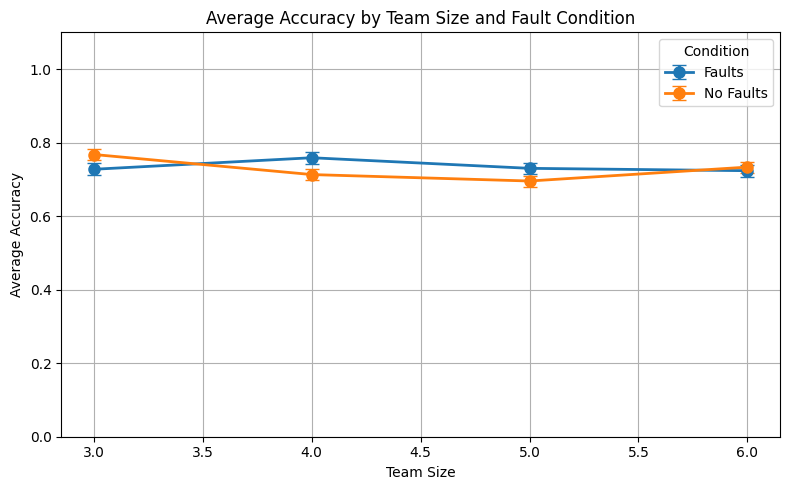

In [9]:
full_team_summary["fault"] = 1
full_team_summary_nofaults["fault"] = 0
all_team_summary = pd.concat([full_team_summary, full_team_summary_nofaults], ignore_index=True)

responses_df["fault"] = 1
responses_df_nofaults["fault"] = 0
responses_df = responses_df[responses_df_nofaults.columns]
all_responses_df = pd.concat([responses_df, responses_df_nofaults], ignore_index=True)

accuracy_summary = (
    all_responses_df
    .dropna(subset=["team_size", "is_correct", "fault"])
    .groupby(["fault", "team_size"])["is_correct"]
    .agg(avg_accuracy="mean", sem_accuracy=sem)
    .reset_index()
)

accuracy_summary["fault_label"] = accuracy_summary["fault"].map({0: "No Faults", 1: "Faults"})

plt.figure(figsize=(8, 5))
for label, group in accuracy_summary.groupby("fault_label"):
    plt.errorbar(
        group["team_size"],
        group["avg_accuracy"],
        yerr=group["sem_accuracy"],
        fmt="o-",
        capsize=5,
        linewidth=2,
        markersize=8,
        label=label,
    )

plt.title("Average Accuracy by Team Size and Fault Condition")
plt.xlabel("Team Size")
plt.ylabel("Average Accuracy")
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

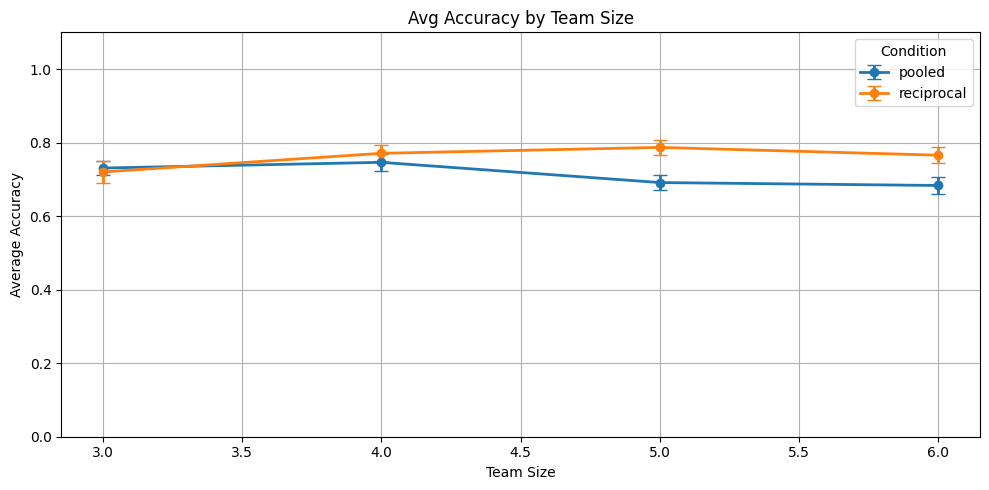

In [10]:
team_meta = full_team_summary.set_index("team_id")[["team_size", "condition"]]

valid_neighborhoods = responses_df["taskId"].dropna().unique()
filtered_responses = responses_df[responses_df["taskId"].isin(valid_neighborhoods)]

filtered_responses = filtered_responses.copy()  
filtered_responses["team_size"] = filtered_responses["team_id"].map(team_meta["team_size"])
filtered_responses["condition"] = filtered_responses["team_id"].map(team_meta["condition"])

filtered_by_size_condition = (
    filtered_responses.dropna(subset=["is_correct", "team_size", "condition"])
    .groupby(["team_size", "condition"])["is_correct"]
    .agg(["mean", sem])
    .reset_index()
    .rename(columns={"mean": "avg_accuracy", "sem": "sem_accuracy"})
)

filtered_by_stage_condition = (
    filtered_responses.dropna(subset=["is_correct", "stage", "condition"])
    .groupby(["stage", "condition"])["is_correct"]
    .agg(["mean", sem])
    .reset_index()
    .rename(columns={"mean": "avg_accuracy", "sem": "sem_accuracy"})
)

filtered_by_stage_and_size_condition = (
    filtered_responses.dropna(subset=["is_correct", "stage", "condition", "team_size"])
    .groupby(["stage", "team_size", "condition"])["is_correct"]
    .agg(["mean", sem])
    .reset_index()
    .rename(columns={"mean": "avg_accuracy", "sem": "sem_accuracy"})
)

plt.figure(figsize=(10, 5))
for condition, group in filtered_by_size_condition.groupby("condition"):
    plt.errorbar(
        group["team_size"],
        group["avg_accuracy"],
        yerr=group["sem_accuracy"],
        label=condition,
        capsize=5,
        marker="o",
        linestyle="-",
        linewidth=2
    )
plt.title("Avg Accuracy by Team Size")
plt.xlabel("Team Size")
plt.ylabel("Average Accuracy")
plt.ylim(0, 1.1)
plt.legend(title="Condition")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
filtered_by_stage_and_size_condition

,stage,team_size,condition,avg_accuracy,sem_accuracy
0,1.0,3,pooled,0.852792,0.025308
1,1.0,3,reciprocal,1.000000,0.000000
2,1.0,4,pooled,0.898438,0.026805
3,1.0,5,pooled,0.824390,0.026639
4,1.0,6,pooled,0.828358,0.032696
5,2.0,3,pooled,0.592179,0.036834
6,2.0,3,reciprocal,0.500000,0.188982
7,2.0,4,pooled,0.578947,0.046446
8,2.0,5,pooled,0.502618,0.036273
9,2.0,6,pooled,0.544118,0.042865


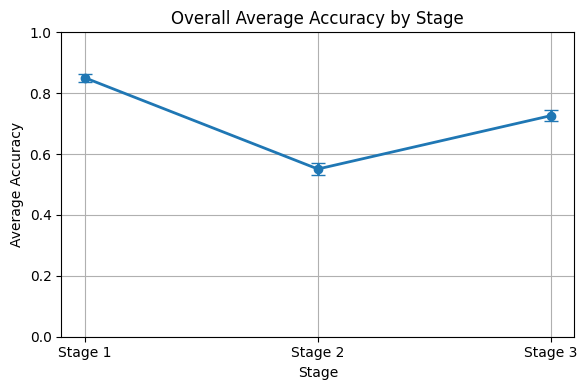

In [12]:
stage_summary = (
    filtered_responses
    .dropna(subset=["is_correct", "stage"])
    .groupby("stage")["is_correct"]
    .agg(["mean", sem])
    .reset_index()
    .rename(columns={"mean": "avg_accuracy", "sem": "sem_accuracy"})
)

# Plot
plt.figure(figsize=(6, 4))
plt.errorbar(
    stage_summary["stage"],
    stage_summary["avg_accuracy"],
    yerr=stage_summary["sem_accuracy"],
    fmt='o-',
    capsize=5,
    linewidth=2,
    markersize=6
)
plt.xticks(stage_summary["stage"], [f"Stage {int(s)}" for s in stage_summary["stage"]])
plt.xlabel("Stage")
plt.ylabel("Average Accuracy")
plt.title("Overall Average Accuracy by Stage")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
dur_summary = (
    responses_df
    .groupby('stage')['durationMs']
    .agg(['mean', sem, 'max', 'count'])
    .reset_index()
    .rename(columns={
        'mean': 'avg_duration_ms',
        'sem':  'sem_duration_ms',
        'max':  'max_duration_ms',
        'count':'n'
    })
)

dur_summary['avg_duration_s'] = dur_summary['avg_duration_ms'] / 1000
dur_summary['sem_duration_s'] = dur_summary['sem_duration_ms'] / 1000
dur_summary['max_duration_s'] = dur_summary['max_duration_ms'] / 1000

print(dur_summary)

   stage  avg_duration_ms  sem_duration_ms  max_duration_ms    n  \
0    1.0     28010.498525      1221.176503           209686  678   
1    2.0     37739.735669      1525.204612           216297  628   
2    3.0     26086.339254      1284.533702           168230  563   

   avg_duration_s  sem_duration_s  max_duration_s  
0       28.010499        1.221177         209.686  
1       37.739736        1.525205         216.297  
2       26.086339        1.284534         168.230  


In [14]:
dur_summary = (
    responses_df_nofaults
    .groupby('stage')['durationMs']
    .agg(['mean', sem, 'max', 'count'])
    .reset_index()
    .rename(columns={
        'mean': 'avg_duration_ms',
        'sem':  'sem_duration_ms',
        'max':  'max_duration_ms',
        'count':'n'
    })
)

dur_summary['avg_duration_s'] = dur_summary['avg_duration_ms'] / 1000
dur_summary['sem_duration_s'] = dur_summary['sem_duration_ms'] / 1000
dur_summary['max_duration_s'] = dur_summary['max_duration_ms'] / 1000

print(dur_summary)

   stage  avg_duration_ms  sem_duration_ms  max_duration_ms    n  \
0    1.0     18175.741158       512.101254           111230  622   
1    2.0     25229.595779       796.415927           210248  616   
2    3.0     15452.930195       390.624017            80915  616   

   avg_duration_s  sem_duration_s  max_duration_s  
0       18.175741        0.512101         111.230  
1       25.229596        0.796416         210.248  
2       15.452930        0.390624          80.915  


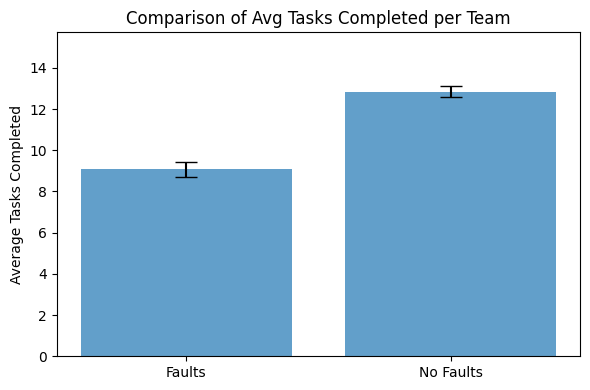

Welch’s t-test: t = -8.528, p = 0.000


In [15]:
mean1, sem1 = full_team_summary["num_tasks_completed"].mean(), full_team_summary["num_tasks_completed"].sem()
mean2, sem2 = full_team_summary_nofaults["num_tasks_completed"].mean(), full_team_summary_nofaults["num_tasks_completed"].sem()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["Faults", "No Faults"],
    [mean1, mean2],
    yerr=[sem1, sem2],
    capsize=8,
    alpha=0.7
)
ax.set_ylabel("Average Tasks Completed")
ax.set_title("Comparison of Avg Tasks Completed per Team")
ax.set_ylim(0, max(mean1 + sem1, mean2 + sem2) * 1.2)
plt.tight_layout()
plt.show()

t_stat, p_val = ttest_ind(
    full_team_summary["num_tasks_completed"],
    full_team_summary_nofaults["num_tasks_completed"],
    equal_var=False  # Welch’s correction
)
print(f"Welch’s t-test: t = {t_stat:.3f}, p = {p_val:.3f}")

In [16]:
full_team_summary["fault"] = 1
full_team_summary_nofaults["fault"] = 0

df = pd.concat([full_team_summary, full_team_summary_nofaults], ignore_index=True)

df = df.rename(columns={
    "num_tasks_completed": "tasks",
    "team_size": "size",
    "condition": "network",
    "num_stages_completed": "stages"
})

df["task_rate"] = df["tasks"]

model = smf.ols("task_rate ~ C(fault) * size * C(network)", data=df).fit()
anova_table = anova_lm(model, typ=2)
print(anova_table)

                               sum_sq     df           F        PR(>F)
C(fault)                   666.644799    1.0  107.480873  5.060197e-20
C(network)                 240.686415    1.0   38.805052  3.253243e-09
C(fault):C(network)         14.398715    1.0    2.321456  1.293653e-01
size                       351.502909    1.0   56.671618  2.431898e-12
C(fault):size               49.492797    1.0    7.979555  5.267844e-03
size:C(network)             21.663351    1.0    3.492708  6.327333e-02
C(fault):size:C(network)     6.487942    1.0    1.046029  3.078037e-01
Residual                  1110.238652  179.0         NaN           NaN


In [17]:
# ---------------------------------------------------------------------------
# Full APA-style stats (F, numerator/denominator df, p, partial eta-squared)
# for the factorial OLS/ANOVA above, for reporting in the manuscript.
# ---------------------------------------------------------------------------

ss_resid = anova_table.loc["Residual", "sum_sq"]
df_den = int(model.df_resid)

stats_table = anova_table.drop(index="Residual").copy()
stats_table["df_num"] = stats_table["df"].astype(int)
stats_table["df_den"] = df_den
stats_table["partial_eta_sq"] = stats_table["sum_sq"] / (stats_table["sum_sq"] + ss_resid)

term_labels = {
    "C(fault)": "Fault condition (main effect)",
    "size": "Team size (main effect)",
    "C(network)": "Team structure (main effect)",
    "C(fault):size": "Fault x Team size",
    "C(fault):C(network)": "Fault x Team structure",
    "size:C(network)": "Team size x Team structure",
    "C(fault):size:C(network)": "Fault x Team size x Team structure",
}

def apa_p(p):
    return "< .001" if p < .001 else f"= {p:.3f}"

print(f"{'Effect':<38}{'F':>8}{'df':>14}{'p':>10}{'partial eta^2':>16}")
print("-" * 86)
for term, label in term_labels.items():
    row = stats_table.loc[term]
    df_str = f"({int(row['df_num'])}, {int(row['df_den'])})"
    print(f"{label:<38}{row['F']:>8.2f}{df_str:>14}{apa_p(row['PR(>F)']):>10}{row['partial_eta_sq']:>16.3f}")

print("\nCopy-ready APA sentences:\n")
for term, label in term_labels.items():
    row = stats_table.loc[term]
    print(
        f"{label}: F({int(row['df_num'])}, {int(row['df_den'])}) = {row['F']:.2f}, "
        f"p {apa_p(row['PR(>F)'])}, partial eta^2 = {row['partial_eta_sq']:.3f}"
    )

Effect                                       F            df         p   partial eta^2
--------------------------------------------------------------------------------------
Fault condition (main effect)           107.48      (1, 179)    < .001           0.375
Team size (main effect)                  56.67      (1, 179)    < .001           0.240
Team structure (main effect)             38.81      (1, 179)    < .001           0.178
Fault x Team size                         7.98      (1, 179)   = 0.005           0.043
Fault x Team structure                    2.32      (1, 179)   = 0.129           0.013
Team size x Team structure                3.49      (1, 179)   = 0.063           0.019
Fault x Team size x Team structure        1.05      (1, 179)   = 0.308           0.006

Copy-ready APA sentences:

Fault condition (main effect): F(1, 179) = 107.48, p < .001, partial eta^2 = 0.375
Team size (main effect): F(1, 179) = 56.67, p < .001, partial eta^2 = 0.240
Team structure (main effect): 

In [18]:
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

df["network"] = df["network"].astype("category")
df["fault"] = df["fault"].astype("category")
df["size"] = df["size"].astype("category")

summary = (
    df.groupby(["fault", "size"])["task_rate"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

pooled_var = (
    ((summary["count"] - 1) * summary["std"]**2).sum() /
    (summary["count"].sum() - summary.shape[0])
)
sigma_pooled = np.sqrt(pooled_var)

means = {}
for _, row in summary.iterrows():
    key = (int(row["fault"]), int(row["size"]))
    value = row["mean"]
    means[key] = value

def simulate_from_empirical_means(n_per_cell, sigma):
    rows = []
    for fault in [0, 1]:
        for size in [3, 4, 5, 6]:
            mu = means[(fault, size)]
            for _ in range(n_per_cell):
                perf = np.random.normal(mu, sigma)
                rows.append(dict(num_tasks_completed=perf, fault=fault, size=size))
    return pd.DataFrame(rows)

def power_fault_size_empirical(n_per_cell, sigma, reps=1000):
    sig_count = 0
    for _ in range(reps):
        df_sim = simulate_from_empirical_means(n_per_cell, sigma)
        df_sim["fault"] = df_sim["fault"].astype("category")
        df_sim["size"] = df_sim["size"].astype("category")
        model = smf.ols("num_tasks_completed ~ fault * size", data=df_sim).fit()
        anova = anova_lm(model, typ=2)
        p = anova.loc["fault:size", "PR(>F)"]
        sig_count += p < 0.05
    return sig_count / reps

# Run for different sample sizes per condition
for n in [2, 4, 6, 8, 10, 12, 20, 40]:
    power = power_fault_size_empirical(n, sigma_pooled)
    print(f"{n} teams per condition → power = {power:.2f}")

/var/folders/rp/drddpy_10vd_hlk0_w76l5_w0000gn/T/ipykernel_66797/2373289660.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["fault", "size"])["task_rate"]


2 teams per condition → power = 0.07


4 teams per condition → power = 0.12


6 teams per condition → power = 0.18


8 teams per condition → power = 0.21


10 teams per condition → power = 0.27


12 teams per condition → power = 0.32


20 teams per condition → power = 0.53


40 teams per condition → power = 0.84


/var/folders/rp/drddpy_10vd_hlk0_w76l5_w0000gn/T/ipykernel_66797/1093772290.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(data=df_bar, x="size", y="task_rate", hue="fault", ci=68)


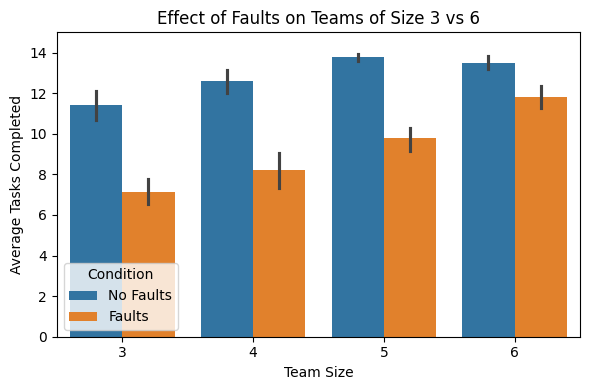

In [19]:
df_bar = df[df["size"].isin([3, 4, 5, 6])].copy()

df_bar["size"] = pd.Categorical(df_bar["size"], categories=[3, 4, 5, 6], ordered=True)
df_bar["fault"] = df_bar["fault"].map({0: "No Faults", 1: "Faults"})

plt.figure(figsize=(6, 4))
sns.barplot(data=df_bar, x="size", y="task_rate", hue="fault", ci=68)
plt.title("Effect of Faults on Teams of Size 3 vs 6")
plt.xlabel("Team Size")
plt.ylabel("Average Tasks Completed")
plt.ylim(0, df_bar["task_rate"].max() + 1)
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

/Users/emieczkowski/miniconda3/envs/socialloafing/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/emieczkowski/miniconda3/envs/socialloafing/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


/Users/emieczkowski/miniconda3/envs/socialloafing/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/emieczkowski/miniconda3/envs/socialloafing/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


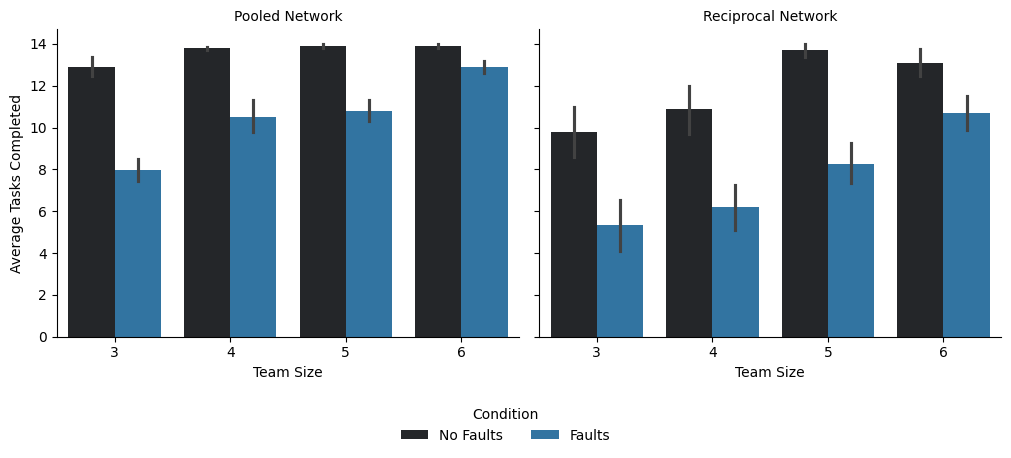

In [20]:
df_bar = df[df["size"].isin([3, 4, 5, 6])].copy()
df_bar["size"] = pd.Categorical(df_bar["size"], categories=[3, 4, 5, 6], ordered=True)
df_bar["fault"] = df_bar["fault"].map({0: "No Faults", 1: "Faults"})
df_bar["network"] = df_bar["network"].map({"pooled": "Pooled", "reciprocal": "Reciprocal"})

g = sns.FacetGrid(df_bar, col="network", height=4, aspect=1)
g.map_dataframe(sns.barplot, x="size", y="task_rate", hue="fault", ci=68, errorbar="ci")
g.set_titles("{col_name} Network")
g.set_axis_labels("Team Size", "Average Tasks Completed")
g.add_legend(title="Condition", loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()